# Lecture 5d — Prediction is not control

**AI-powered Investment and Risk Management**

Reinforcement learning is the most oversold technique in quantitative finance, and it is oversold for an interesting reason: the demonstrations almost always use it on problems that are not control problems at all.

This notebook gives you a test. One question, answerable in a few lines of code, that tells you whether reinforcement learning has anything to offer your problem or whether you are using a very expensive tool to estimate a conditional mean.

We will apply it twice. Once to a trading agent — the kind in most tutorials — where it returns a clear no. Once to an order-execution problem, where it returns a clear yes and the agent goes on to beat its benchmark by 8%.

**What you will be able to do afterwards**

- Identify the defect that makes most tabular RL trading demonstrations meaningless
- State and apply the discount-factor diagnostic
- Explain why the Bellman equation collapses when actions do not move the state
- Build a small execution environment and solve it with tabular Q-learning
- Say precisely what an RL agent has learnt, and what it has merely memorised about your simulator

**Runtime** — about three minutes; the seed sweep in §2 is most of it.

---

In [7]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots

import airm5 as a
from airm5 import C, style

pd.set_option("display.float_format", lambda v: f"{v:,.3f}")

## 1. Last year's lab, and the bug that emptied it

Here is the price generator used in this subject's Lecture 5 lab last year, reproduced exactly. Read it before running it.

In [8]:
def generate_stock_prices(S0, mu, sigma, n_steps):
    """Last year's generator, verbatim."""
    dt = 1 / n_steps
    prices = [S0]
    for _ in range(n_steps - 1):
        S_t = prices[-1] * np.exp((mu - 0.5 * sigma ** 2) * dt
                                  + sigma * np.sqrt(dt) * np.random.randn())
        prices.append(S_t)
    return np.array(prices)

S0, N_STEPS = 100, 200
mu_daily, sigma_daily = 0.05 / 252, 0.20 / np.sqrt(252)     # already per-day

np.random.seed(0)
paths = [generate_stock_prices(S0, mu_daily, sigma_daily, N_STEPS) for _ in range(200)]

print(f"Per-step volatility implied : {sigma_daily*np.sqrt(1/N_STEPS):.6f} "
      f"({sigma_daily*np.sqrt(1/N_STEPS)*100:.4f}% of a $100 share)")
print(f"Mean high-low range         : ${np.mean([p.max()-p.min() for p in paths]):.2f} "
      f"over the whole 200-step path")
print(f"Distinct integer price levels visited (the agent's state buckets): "
      f"{np.mean([len(set((p//1).astype(int))) for p in paths]):.1f} of 200")

Per-step volatility implied : 0.000891 (0.0891% of a $100 share)
Mean high-low range         : $1.93 over the whole 200-step path
Distinct integer price levels visited (the agent's state buckets): 3.0 of 200


The parameters are already daily — `mu` is divided by 252 and `sigma` by $\sqrt{252}$ before the call. The function then divides again by `n_steps`. Everything is scaled twice.

The consequence is not a slightly wrong volatility. The price wanders **less than two dollars over the entire path**, and since the agent's state is `int(price // 1)`, it visits about three of its two hundred Q-table rows. Ninety-eight and a half per cent of the table stays at its initial value of zero, and `argmax` on a row of zeros returns action 0 — Hold — so the agent mostly does nothing and the learning curve is an artefact of nothing.

In [9]:
def gbm(S0, mu, sigma, n, rng):
    """Correctly scaled: the parameters are already per-step."""
    return S0 * np.exp(np.cumsum((mu - 0.5 * sigma ** 2) + sigma * rng.standard_normal(n)))

rng = np.random.default_rng(0)
fixed = [gbm(S0, mu_daily, sigma_daily, N_STEPS, rng) for _ in range(200)]

comparison = pd.DataFrame({
    "": ["Mean high–low range", "State buckets visited (of 200)"],
    "Last year's code": [f"${np.mean([p.max()-p.min() for p in paths]):.2f}",
                         f"{np.mean([len(set((p//1).astype(int))) for p in paths]):.1f}"],
    "Correctly scaled": [f"${np.mean([p.max()-p.min() for p in fixed]):.2f}",
                         f"{np.mean([len(set((p//1).astype(int))) for p in fixed]):.1f}"],
})
print(comparison.to_string(index=False))

                               Last year's code Correctly scaled
           Mean high–low range            $1.93           $28.35
State buckets visited (of 200)              3.0             28.0


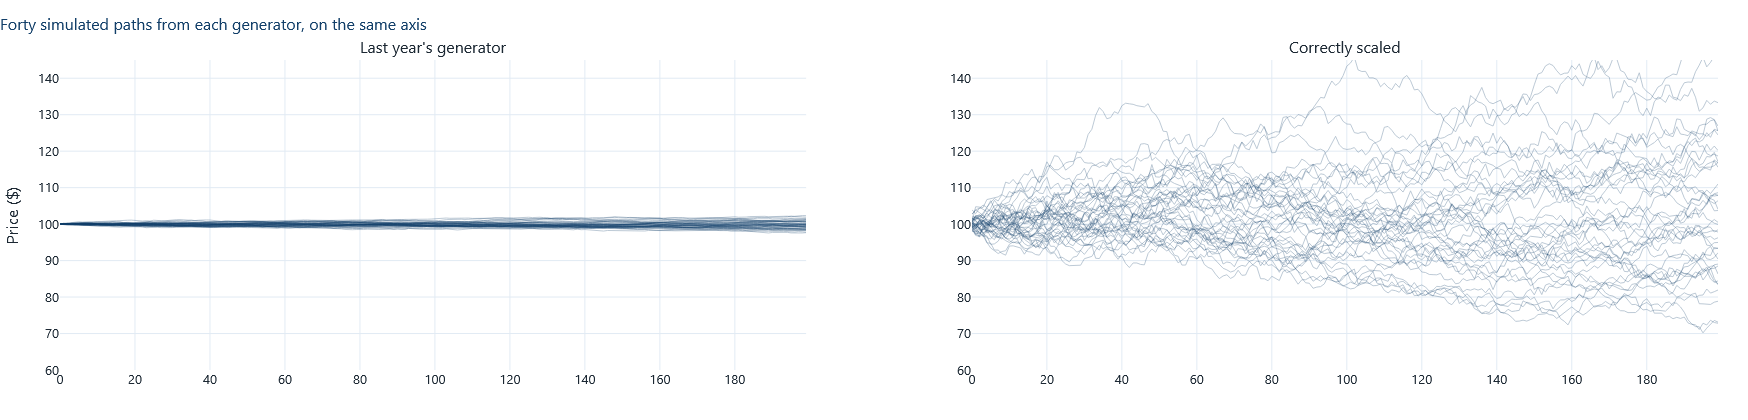

In [10]:
fig = make_subplots(rows=1, cols=2, subplot_titles=("Last year's generator",
                                                    "Correctly scaled"))
for i, group in enumerate([paths, fixed]):
    for p in group[:40]:
        fig.add_trace(go.Scatter(y=p, line=dict(color=C["navy"], width=0.8),
                                 opacity=0.35, showlegend=False), row=1, col=i + 1)
fig.update_yaxes(range=[60, 145], title="Price ($)", row=1, col=1)
fig.update_yaxes(range=[60, 145], row=1, col=2)
style(fig, height=420, legend_top=False,
      title="Forty simulated paths from each generator, on the same axis")
fig.show()

That is a coding defect and it is now fixed. But repairing it does not rescue the exercise, and the reason is the substance of this notebook.

## 2. The question that decides whether RL applies

Ask this: **does my action change what happens next?**

In the trading agent, it does not. Buying a share does not move the market, so the price path is the same whatever the agent does. The agent's position changes; the *world* does not.

There is a two-line test for this, and it is more reliable than reasoning about it. Train the agent at several discount factors. If the learned policy does not change, you do not have a control problem.

In [11]:
def ar1_returns(n, phi=0.15, sd=0.01, seed=0):
    """Returns with a little momentum, so there is genuinely something to learn."""
    rr = np.random.default_rng(seed)
    e = rr.standard_normal(n + 1) * sd
    r = np.zeros(n + 1)
    for t in range(1, n + 1):
        r[t] = phi * r[t - 1] + e[t]
    return r[1:]

def q_trade(r, gamma, n_states=8, passes=40, alpha=0.1, eps=0.25, seed=0):
    """Tabular Q-learning. State = bucketed previous return. Action = flat or long."""
    rr = np.random.default_rng(seed)
    edges = np.quantile(r, np.linspace(0, 1, n_states + 1)[1:-1])
    bucket = lambda x: int(np.clip(np.digitize(x, edges), 0, n_states - 1))
    Q = np.zeros((n_states, 2))
    for _ in range(passes):
        for t in range(len(r) - 2):
            s, s_next = bucket(r[t]), bucket(r[t + 1])
            act = rr.integers(2) if rr.random() < eps else int(np.argmax(Q[s]))
            target = act * r[t + 1] + gamma * Q[s_next].max()
            Q[s, act] += alpha * (target - Q[s, act])
    return Q, edges

def trade_sharpe(Q, edges, r):
    b = np.clip(np.digitize(r[:-1], edges), 0, len(Q) - 1)
    g = Q.argmax(axis=1)[b] * r[1:]
    return 0.0 if g.std() == 0 else g.mean() / g.std() * np.sqrt(252)

r_test = ar1_returns(6000, seed=999)
SEEDS = range(6)

diag = []
for gamma in [0.0, 0.5, 0.9, 0.99]:
    vals = []
    for sd in SEEDS:
        r_train = ar1_returns(6000, seed=sd)
        Q, edges = q_trade(r_train, gamma, seed=sd)
        vals.append(trade_sharpe(Q, edges, r_test))
    diag.append({"γ": gamma, "Mean Sharpe": np.mean(vals),
                 "SD across seeds": np.std(vals)})
diag = pd.DataFrame(diag)
print(diag.to_string(index=False))
print(f"\nSpread across discount factors : "
      f"{diag['Mean Sharpe'].max() - diag['Mean Sharpe'].min():.2f}")
print(f"Typical spread across seeds    : {diag['SD across seeds'].mean():.2f}")

    γ  Mean Sharpe  SD across seeds
0.000        0.909            0.666
0.500        0.844            0.623
0.900        0.932            0.531
0.990        1.057            0.603

Spread across discount factors : 0.21
Typical spread across seeds    : 0.61


A discount factor of 0 means "ignore the future entirely"; 0.99 means "the future is nearly as important as now". The gap between them is smaller than the gap between two random seeds.

That is the finding, and it is worth stating carefully rather than triumphantly. The discount factor is the single parameter that controls how much sequential reasoning the agent does, and turning it from 0 to 0.99 has no effect distinguishable from noise — because in this environment **the future is not affected by what you do**, so weighing it differently changes nothing that matters.

Every piece of machinery that distinguishes reinforcement learning from supervised learning — bootstrapping, credit assignment over time, the exploration–exploitation trade-off in a sequential setting — is idle here. What the agent has computed is $\mathbb{E}[r_{t+1} \mid s_t]$ in eight buckets, which is a conditional mean, which is a supervised learning problem.

<details>
<summary><b>The maths: why the Bellman equation collapses</b></summary>

The action-value function satisfies

$$Q(s,a) = \mathbb{E}\big[r \mid s,a\big] + \gamma\, \mathbb{E}\big[\max_{a'} Q(s',a') \mid s,a\big]$$

Now suppose the transition distribution does not depend on the action: $P(s' \mid s,a) = P(s' \mid s)$. The second term becomes $\gamma\,\mathbb{E}[\max_{a'} Q(s',a') \mid s]$, which is **the same number for every $a$ in state $s$**. Adding a constant to every action in a state cannot change which action is largest, so

$$\arg\max_a Q(s,a) = \arg\max_a \mathbb{E}[r \mid s,a]$$

for every $\gamma$. The optimal policy is one-step greedy on the expected immediate reward. There is no sequential problem to solve — only a conditional expectation to estimate, and supervised learning estimates conditional expectations more efficiently, with better-understood error bars, and without the exploration cost.

One honest caveat about the empirical version. The invariance above is a statement about the *converged* action-value function. Tabular Q-learning estimates the bootstrap term separately for each action from whichever transitions happened to follow it, so in finite samples that term carries noise that differs by action, and a marginal state can flip. This is why the table reports means and seed dispersion rather than claiming the policies are bit-identical: the right comparison is whether the discount factor moves performance by more than the noise floor, not whether two arrays match exactly.
</details>

**The diagnostic, stated plainly.**

> Retrain your agent at $\gamma = 0$ and at $\gamma = 0.95$. If the policy is unchanged, your problem is prediction wearing control's clothing. Use a supervised model and a decision rule, and keep the interpretability.

This is worth running before any RL project in finance, because it takes minutes and it disqualifies most of them.

## 3. Execution: where the state genuinely moves

Now a problem where the answer is different.

You must sell 100,000 shares over ten intervals. Trading moves the price against you: sell more in one interval and you get a worse price for that interval. Liquidity varies across the day — deep at the open and the close, thinner in the middle — so the cost of trading a given size is not constant.

Here your action changes the state in the most direct way possible: whatever you sell now, you no longer hold, and every future decision is constrained by it.

In [12]:
T, X0 = 10, 100.0                          # ten intervals, 100 units (thousands of shares)
eta = 1.0 + 1.5 * np.sin(np.pi * np.arange(T) / (T - 1))   # impact: cheap at the ends

def impact_cost(schedule):
    """Total temporary-impact cost of a liquidation schedule."""
    return float(np.sum(eta * np.asarray(schedule) ** 2))

twap = np.full(T, X0 / T)                              # the industry default
optimal = (1 / eta) / np.sum(1 / eta) * X0             # closed form, derived below

print(f"Impact coefficient by interval : {np.round(eta, 2)}\n")
print(f"TWAP cost              : {impact_cost(twap):8.1f}")
print(f"Closed-form optimum    : {impact_cost(optimal):8.1f}  "
      f"({impact_cost(optimal)/impact_cost(twap)-1:+.1%} against TWAP)")

Impact coefficient by interval : [1.   1.51 1.96 2.3  2.48 2.48 2.3  1.96 1.51 1.  ]

TWAP cost              :   1850.7
Closed-form optimum    :   1661.9  (-10.2% against TWAP)


<details>
<summary><b>The maths: the optimal schedule when impact is quadratic</b></summary>

With temporary impact cost $\eta_t v_t^2$ in interval $t$, total cost is $\sum_t \eta_t v_t^2$ subject to $\sum_t v_t = X$. The Lagrangian is

$$\mathcal{L} = \sum_t \eta_t v_t^2 - \lambda\Big(\sum_t v_t - X\Big), \qquad
\frac{\partial \mathcal{L}}{\partial v_t} = 2\eta_t v_t - \lambda = 0$$

so $v_t \propto 1/\eta_t$: trade in inverse proportion to the cost of trading. If $\eta_t$ is constant this is exactly TWAP, which is why TWAP is the right default and why beating it requires liquidity that actually varies.

We have a closed form here only because the environment is simple. Add a bid–ask spread, a minimum lot size, a participation-rate cap, cross-impact between assets, or an adversary who detects your schedule, and the analytic solution disappears while the RL formulation survives unchanged. **That robustness to specification, not raw performance, is the real argument for RL in execution.**
</details>

In [13]:
ACTIONS = np.array([0.0, 0.05, 0.10, 0.15, 0.20, 0.25, 0.35, 0.50, 1.0])  # fraction of remaining
N_INV = 21                                                                 # inventory buckets

def q_execute(gamma=1.0, episodes=60000, alpha0=0.30, seed=0, track_every=None):
    """Tabular Q-learning over (interval, inventory) -> fraction of remaining to sell."""
    rr = np.random.default_rng(seed)
    Q = np.zeros((T, N_INV, len(ACTIONS)))
    history = []
    for ep in range(episodes):
        eps = max(0.05, 1.0 - ep / (episodes * 0.6))
        alpha = alpha0 * (1 - ep / episodes) + 0.02
        inv = X0
        for t in range(T):
            s = int(round(inv / X0 * (N_INV - 1)))
            act = (rr.integers(len(ACTIONS)) if rr.random() < eps
                   else int(np.argmax(Q[t, s])))
            v = inv if t == T - 1 else ACTIONS[act] * inv      # must finish by T
            reward = -eta[t] * v ** 2 / X0 ** 2                # scaled for stable updates
            inv -= v
            s_next = int(round(inv / X0 * (N_INV - 1)))
            target = reward if t == T - 1 else reward + gamma * Q[t + 1, s_next].max()
            Q[t, s, act] += alpha * (target - Q[t, s, act])
        if track_every and ep % track_every == 0:
            history.append((ep, impact_cost(greedy_schedule(Q))))
    return (Q, history) if track_every else Q

def greedy_schedule(Q):
    """Follow the learned policy with no exploration."""
    inv, out = X0, []
    for t in range(T):
        s = int(round(inv / X0 * (N_INV - 1)))
        v = inv if t == T - 1 else ACTIONS[int(np.argmax(Q[t, s]))] * inv
        out.append(v)
        inv -= v
    return np.array(out)

rows = [{"Policy": "TWAP", "Cost": impact_cost(twap), "vs TWAP": 0.0},
        {"Policy": "Closed-form optimum", "Cost": impact_cost(optimal),
         "vs TWAP": impact_cost(optimal) / impact_cost(twap) - 1}]
learned = {}
for gamma in [0.0, 0.5, 0.9, 1.0]:
    sched = greedy_schedule(q_execute(gamma, seed=0))
    learned[gamma] = sched
    rows.append({"Policy": f"Q-learning, γ = {gamma}", "Cost": impact_cost(sched),
                 "vs TWAP": impact_cost(sched) / impact_cost(twap) - 1})
exec_table = pd.DataFrame(rows)
exec_table["vs TWAP"] = (exec_table["vs TWAP"] * 100).round(1).astype(str) + " %"
print(exec_table.to_string(index=False))

             Policy       Cost vs TWAP
               TWAP  1,850.692   0.0 %
Closed-form optimum  1,661.854 -10.2 %
Q-learning, γ = 0.0 10,000.000 440.3 %
Q-learning, γ = 0.5  5,038.048 172.2 %
Q-learning, γ = 0.9  1,870.154   1.1 %
Q-learning, γ = 1.0  1,702.083  -8.0 %


Read the discount factor column against §2.

At $\gamma = 0$ the agent sells everything immediately — it cares only about the current reward, and since selling now avoids no cost it dumps the lot and pays five times the TWAP cost. At $\gamma = 1$ it beats TWAP by 8% and lands within 2.4% of the analytic optimum.

**The policy changes enormously with $\gamma$.** That is what a real control problem looks like, and it is exactly the response the trading agent failed to give.

Put the two diagnostics side by side. In the trading environment, moving $\gamma$ from 0 to 0.99 changed held-out performance by less than the variation between random seeds. Here it changes the cost by a factor of six, and — because the environment is deterministic given the schedule — repeating with different seeds changes nothing at all. The signal-to-noise ratio of the diagnostic is the diagnostic.

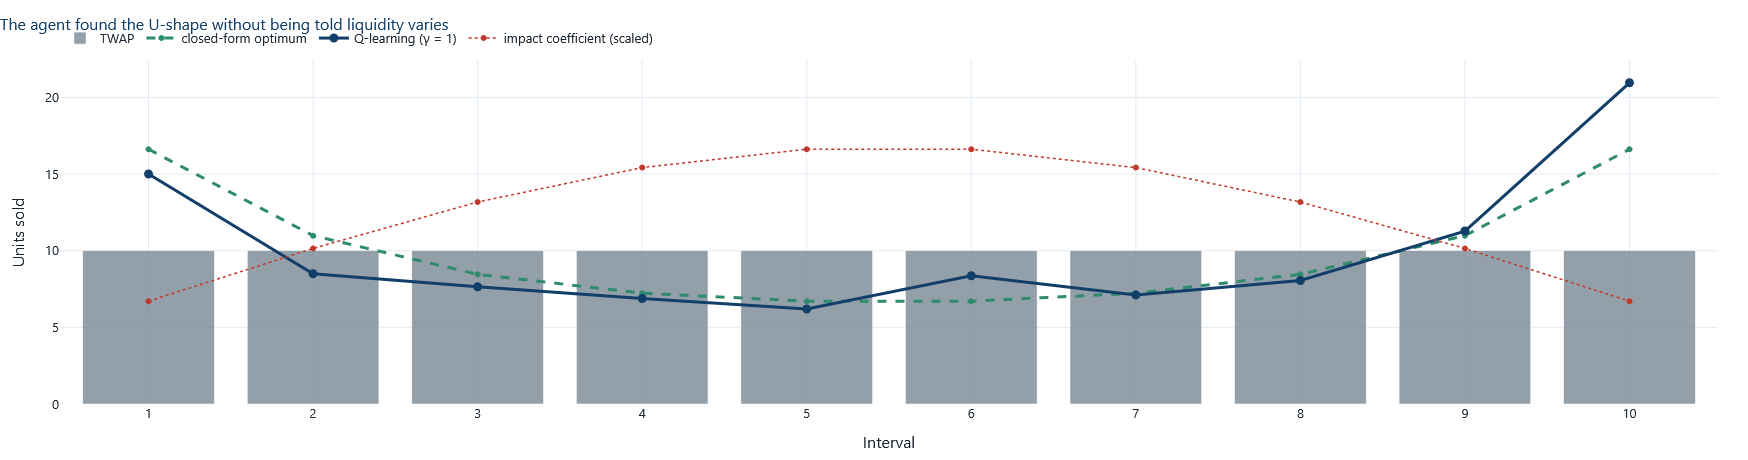

In [14]:
fig = go.Figure()
fig.add_trace(go.Bar(x=np.arange(1, T + 1), y=twap, name="TWAP",
                     marker_color=C["grey"], opacity=0.8))
fig.add_trace(go.Scatter(x=np.arange(1, T + 1), y=optimal, name="closed-form optimum",
                         mode="lines+markers", line=dict(color=C["green"], width=3,
                                                         dash="dash")))
fig.add_trace(go.Scatter(x=np.arange(1, T + 1), y=learned[1.0], name="Q-learning (γ = 1)",
                         mode="lines+markers", line=dict(color=C["navy"], width=3),
                         marker=dict(size=9)))
fig.add_trace(go.Scatter(x=np.arange(1, T + 1), y=eta / eta.max() * optimal.max(),
                         name="impact coefficient (scaled)", yaxis="y",
                         line=dict(color=C["red"], width=1.5, dash="dot")))
fig.update_xaxes(title="Interval", dtick=1)
fig.update_yaxes(title="Units sold")
style(fig, height=460,
      title="The agent found the U-shape without being told liquidity varies")
fig.show()

The agent was never given `eta`. It saw only rewards, and from those it recovered the shape of the optimal schedule: trade heavily at the open and the close, hold back through the illiquid middle.

That is a genuine result and it is the honest advertisement for reinforcement learning in finance. Not "RL predicts markets". **RL solves scheduling problems where your own actions are part of the environment.**

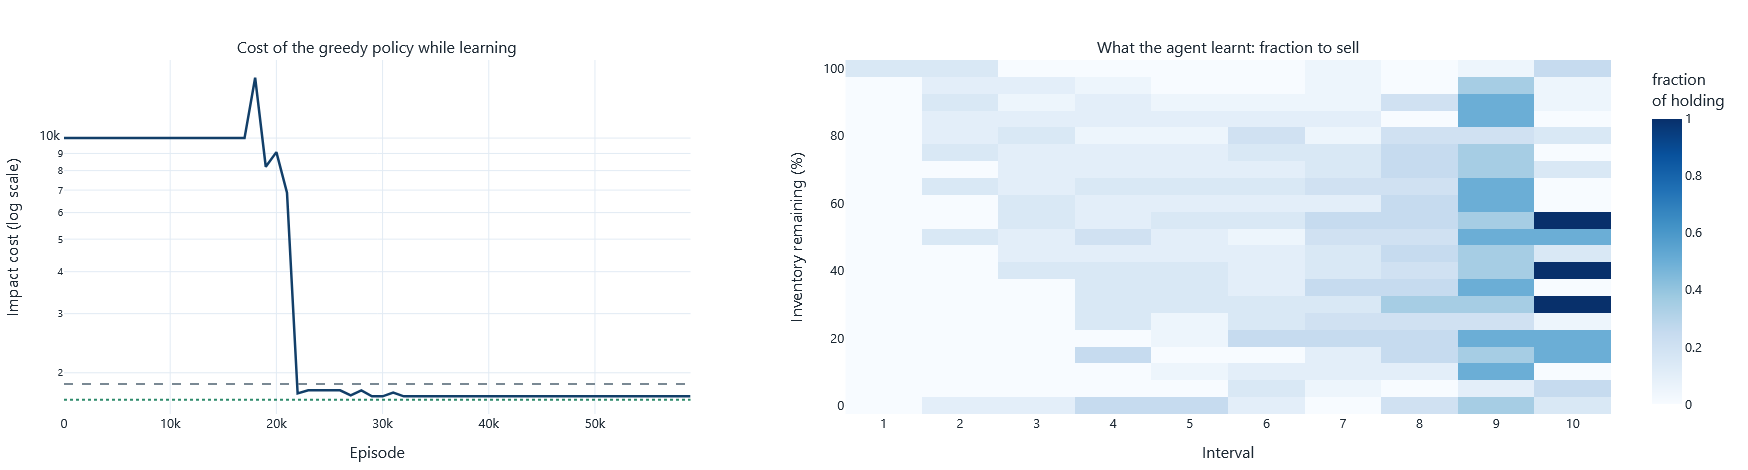

In [15]:
Q_final, history = q_execute(1.0, seed=0, track_every=1000)
hist = pd.DataFrame(history, columns=["episode", "cost"])

fig = make_subplots(rows=1, cols=2, column_widths=[0.45, 0.55],
                    subplot_titles=("Cost of the greedy policy while learning",
                                    "What the agent learnt: fraction to sell"))
fig.add_trace(go.Scatter(x=hist.episode, y=hist.cost, line=dict(color=C["navy"], width=2.5),
                         name="learned policy"), row=1, col=1)
fig.add_hline(y=impact_cost(twap), line=dict(color=C["grey"], width=2, dash="dash"),
              annotation_text="TWAP", row=1, col=1)
fig.add_hline(y=impact_cost(optimal), line=dict(color=C["green"], width=2, dash="dot"),
              annotation_text="optimum", row=1, col=1)
fig.update_yaxes(type="log", title="Impact cost (log scale)", row=1, col=1)
fig.update_xaxes(title="Episode", row=1, col=1)

policy_grid = np.array([[ACTIONS[int(np.argmax(Q_final[t, s]))] for t in range(T)]
                        for s in range(N_INV)])
fig.add_trace(go.Heatmap(z=policy_grid, x=np.arange(1, T + 1),
                         y=np.round(np.linspace(0, 100, N_INV), 0),
                         colorscale="Blues", colorbar=dict(title="fraction<br>of holding"),
                         hovertemplate="interval %{x}<br>holding %{y}%<br>"
                                       "sell %{z:.0%} of it<extra></extra>"), row=1, col=2)
fig.update_xaxes(title="Interval", dtick=1, row=1, col=2)
fig.update_yaxes(title="Inventory remaining (%)", row=1, col=2)
style(fig, height=470, legend_top=False, title="")
fig.show()

The right-hand panel is the learned policy in full: for every interval and every level of remaining inventory, the fraction it would sell. The bright column on the right is the forced liquidation in the final interval. Note that the policy is nearly flat in inventory — the agent discovered that the right *fraction* of remaining stock depends on time but barely on how much is left, which is precisely the structure of the closed-form solution.

The left-hand panel is worth a caution. That curve is the cost of the greedy policy measured **in the same simulator the agent is training on**. It is a learning curve, not evidence of anything about the world.

## 4. Four reasons this is harder than it looks

**The agent optimises your simulator, not the market.** Our environment says impact is $\eta_t v^2$ with a known, stationary, inverted-U profile. The agent learnt that profile beautifully. A real market's impact function is unknown, non-stationary, and changes when other participants notice your schedule. An agent trained on a wrong simulator learns the wrong policy with complete confidence, and nothing in its training signal will tell you.

**Sample efficiency.** Sixty thousand episodes for a problem with 10 intervals, 21 inventory states and 9 actions. That is roughly 300 visits per state–action pair, on a problem whose analytic solution is one line of calculus. Realistic state spaces — limit order book depth, multiple venues, several assets — grow the table far beyond what any history can populate, which is where deep RL enters and where the sample requirements become genuinely severe.

**Reward hacking.** The agent maximises exactly what you wrote down. Reward it for average execution price and it will happily wait until the last interval and take the risk; reward it for filling early and it will pay any cost to do so. Every constraint you care about but did not encode is a constraint the agent will discover it can violate.

**Collusion.** This one is a regulatory problem rather than a technical one. Independent pricing agents trained by reinforcement learning, with no communication channel and no instruction to cooperate, have been shown in experimental settings to converge on supra-competitive prices — they learn that undercutting invites retaliation. Nobody wrote a cartel. The behaviour is emergent, which makes it difficult to detect, difficult to attribute, and genuinely unclear in law.

## 5. What to take away

1. **Run the discount-factor test first.** Train at $\gamma = 0$ and $\gamma = 0.95$; if the policy is unchanged, you have a prediction problem and should use a supervised model.
2. **When actions do not move the state, the Bellman equation collapses** to a one-step conditional expectation. This is a theorem, not a heuristic.
3. **Most RL-for-trading demonstrations fail this test**, including the one this subject used last year — which additionally had a scaling bug that left 98.5% of its Q-table untouched.
4. **Execution passes the test decisively.** The learned policy went from five times the TWAP cost at $\gamma = 0$ to 8% better than TWAP at $\gamma = 1$.
5. **The agent recovered the U-shaped schedule without being told liquidity varies** — and got within 2.4% of the analytic optimum.
6. **The argument for RL in execution is robustness, not performance.** The closed form dies the moment you add a participation cap or a spread; the RL formulation does not change at all.
7. **A learning curve measured inside your own simulator is not evidence about the world.**

Where reinforcement learning genuinely belongs in finance is where the deck placed it: execution, market making, and hedging under frictions. All three are control problems. Forecasting returns is not.

## Exercises

**Core**

1. Run the discount-factor diagnostic on a modified trading environment in which the agent pays a cost proportional to turnover. Does the policy now depend on $\gamma$? Explain what changed, and be precise about whether the *state* changed or only the reward.
2. Set `eta` to a constant vector and re-run §3. What schedule does the agent learn, and what does that tell you about when TWAP is hard to beat?
3. The agent is forced to liquidate everything in the final interval. Remove that constraint and add a penalty for unsold inventory instead. How large must the penalty be before the agent still finishes?
4. Change the action grid to `[0, 0.25, 0.5, 0.75, 1.0]` and re-run. How much of the improvement over TWAP survives, and why?

**Stretch**

5. Add a bid–ask spread — a fixed cost per unit traded, regardless of size — and re-derive the optimal schedule analytically if you can. Then check whether Q-learning finds it. Which approach coped better with the change?
6. Give the environment a mean-reverting price in addition to impact, so that the agent has both a timing motive and a cost motive. Does the learned schedule still resemble the U-shape? Does the discount-factor diagnostic still return a clear yes?
7. Implement a second agent selling the same asset over the same window, with each agent's impact affecting the other. Train them together. Do they learn to trade at different times, and what is the competitive interpretation of that outcome?
8. Replace the tabular Q-table with a small neural network taking `(t, inventory)` as input. Measure how many episodes it needs to match the tabular result, and argue whether the added flexibility was worth it at this problem size.